Visualize out of shelter runs

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [5]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from behave_analysis.analyze.CCA.find_shelter_exit_and_runs import find_shelter_exit_runs, find_bout_runs
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe
from behave_analysis.utils.arena_plotting import Arena

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import os

%matplotlib inline
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
COLUMNS_TO_KEEP = ["hdir", "mouse_x_position", "mouse_y_position", "speed", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
session_name = list(experiments_objects.keys())[8]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
session_start = max(session.shelter_time[0]*60*40, 30*40) # start at shelter_time or 30s, whichever is later
# video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
shelter_outings = find_shelter_exit_runs(
    video_df,
    min_speed_cm_s=5.0,
    min_distance_cm=20.0,
)
bout_runs = find_bout_runs(video_df, min_distance_cm=40, remove_shelter_outings=True)

2026-04-20 10:15:56.393 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [ ]:
cap = 20
bool_vec, bool_name = bout_runs, "Bout runs"
# bool_vec, bool_name = shelter_outings, "Shelter outings"
# bool_name = "Homing + escapes"

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex="row", sharey="row")
for c, cond in enumerate(cond_list):
    if bool_name == "Homing + escapes":
        indices = (
            filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=False, select_homings=True, select_escape=True)["frames"].to_numpy() - 1
        )
    else:
        frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
        indices = [idx for idx in frames_by_condition_explore if idx in np.where(bool_vec)[0]]
    # plot speed traces
    Arena(ax=axs[1,c], condition=cond, barrier_coordinates=session.barrier_location[:-1], full_image=False)
    start = np.concatenate([np.zeros(1), np.where(np.diff(indices) > 1)[0] + 1, np.array([len(indices)])]).astype(int)
    for s in range(len(start[:-1])):
        if s > cap:
            break
        seg = indices[start[s]:start[s + 1]]
        axs[0,c].plot(video_df["speed"].to_numpy()[seg], color = 'blue', alpha = 0.5)
        axs[1,c].scatter(video_df["mouse_x_position"].to_numpy()[seg], video_df["mouse_y_position"].to_numpy()[seg], 
                         c = np.linspace(0, 1, len(seg)) if len(seg) > 1 else np.array([0.0]), cmap = "cool",
                         s=2, alpha = 0.2, label = "Out of shelter runs" if s == 0 else None)
    axs[0,c].set_title(f"{cond_list[c]}")
    
    fig.suptitle(bool_name)

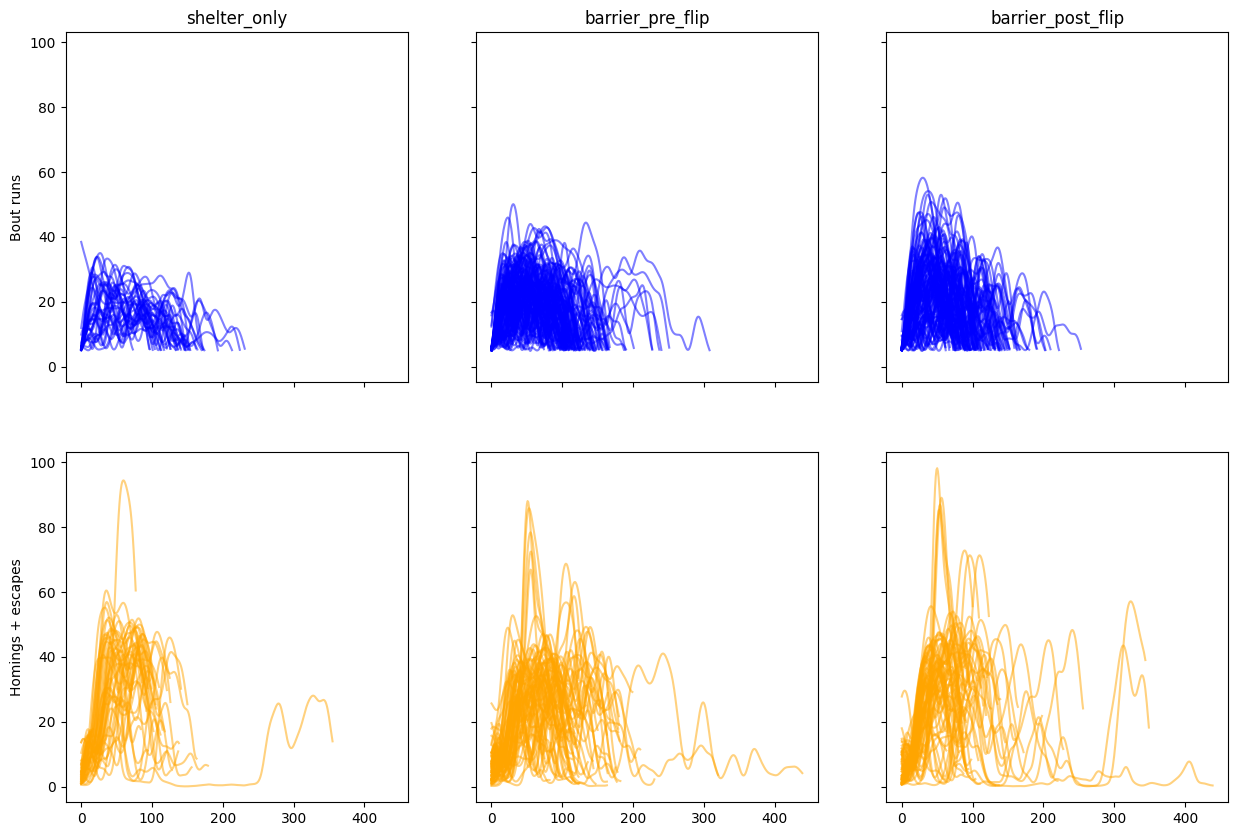

In [4]:
bool_vec, bool_name = bout_runs, "Bout runs"
# bool_vec, bool_name = shelter_outings, "Shelter outings"

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
for c, cond in enumerate(cond_list):
    frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
    homing_indices = (
        filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=False, select_homings=True, select_escape=True)["frames"].to_numpy() - 1
    )
    explore_test_idx = [idx for idx in frames_by_condition_explore if idx in np.where(bool_vec)[0]]
    start = np.concatenate([np.zeros(1), np.where(np.diff(explore_test_idx) > 1)[0] + 1, np.array([len(explore_test_idx)])]).astype(int)
    for s in range(len(start[:-1])):
        axs[0,c].plot(video_df["speed"].to_numpy()[explore_test_idx][start[s]:start[s+1]], color = 'blue', alpha = 0.5)
    axs[0,c].set_title(f"{cond_list[c]}")
    start = np.concatenate([np.zeros(1), np.where(np.diff(homing_indices) > 1)[0] + 1, np.array([len(homing_indices)])]).astype(int)
    for s in range(len(start[:-1])):
        axs[1,c].plot(video_df["speed"].to_numpy()[homing_indices][start[s]:start[s+1]], color = 'orange', alpha = 0.5)
    if c == 0:
        axs[0,c].set_ylabel(bool_name)
        axs[1,c].set_ylabel("Homings + escapes")

291


(-3.141592653589793, 3.141592653589793)

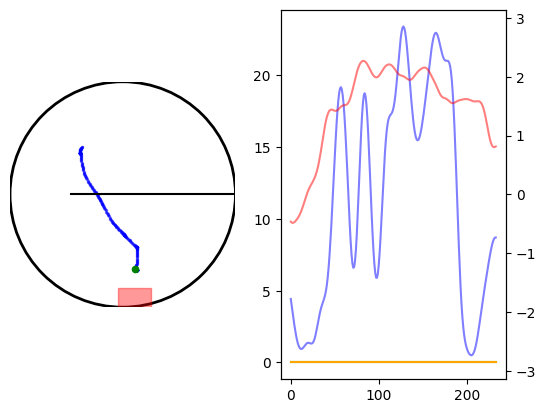

In [78]:
start = np.where(np.diff(bout_runs.astype(int)) == 1)[0] + 1
print(len(start))
end = np.where(np.diff(bout_runs.astype(int)) == -1)[0] + 1
fig,axs = plt.subplots(1,2)
Arena(ax=axs[0], condition=cond, barrier_coordinates=session.barrier_location[:-1], full_image=False)
s = 6
axs[0].scatter(video_df["mouse_x_position"].to_numpy()[start[s]-40:end[s]+40], video_df["mouse_y_position"].to_numpy()[start[s]-40:end[s]+40], color = 'blue', alpha = 0.5, s=2)
axs[0].scatter(video_df["mouse_x_position"].to_numpy()[start[s]], video_df["mouse_y_position"].to_numpy()[start[s]], color = 'green', alpha = 1, s=20)
axs[1].plot(video_df["speed"].to_numpy()[start[s]-40:end[s]+40], color = 'blue', alpha = 0.5)
axs[1].plot(video_df["homingPeriod"].to_numpy()[start[s]-40:end[s]+40].astype(int)*2, color = 'green', alpha = 1)
axs[1].plot(shelter_outings.astype(int)[start[s]-40:end[s]+40]*2, color = 'orange', alpha = 1)
a = axs[1].twinx()
a.plot(video_df["hdir"].to_numpy()[start[s]-40:end[s]+40], color = 'red', alpha = 0.5)
a.set_ylim(-np.pi,np.pi)

KeyboardInterrupt: 

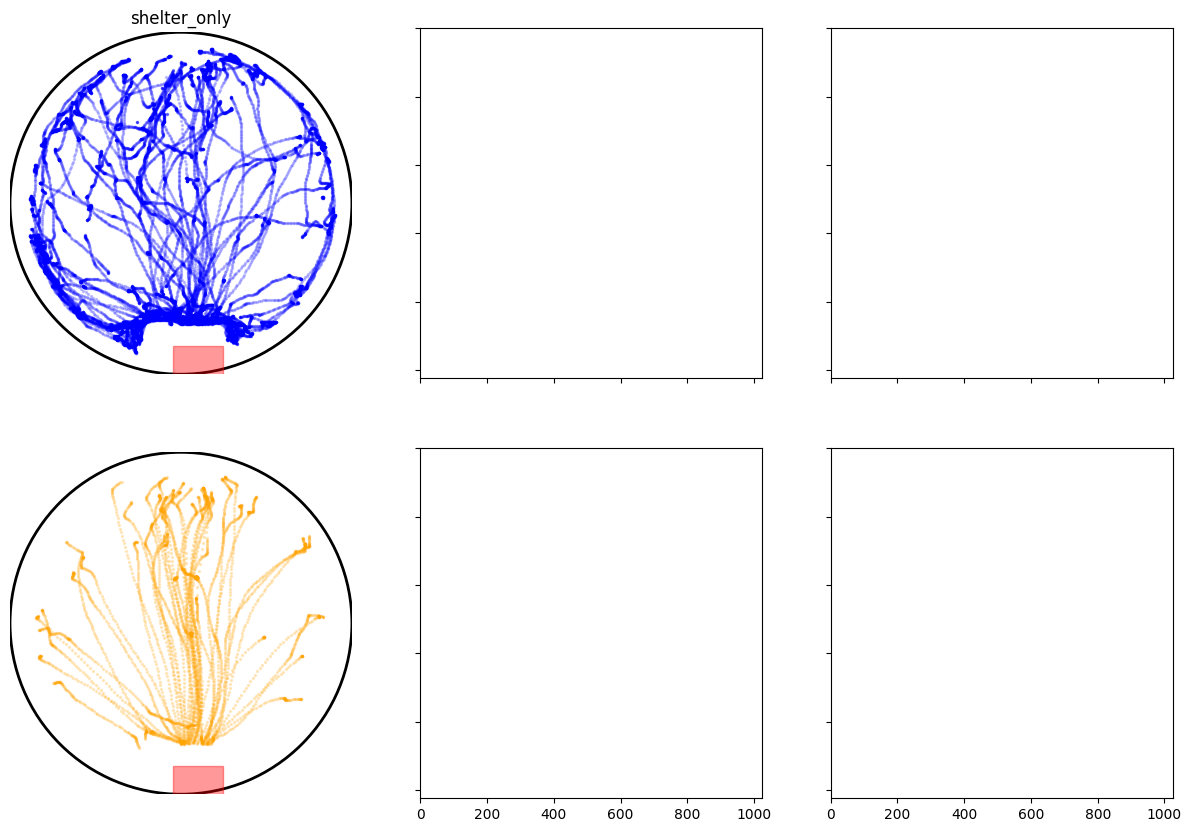

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
for c, cond in enumerate(cond_list):
    frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
    homing_indices = (
        filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=False, select_homings=True, select_escape=True)["frames"].to_numpy() - 1
    )
    explore_test_idx = [idx for idx in frames_by_condition_explore if idx in np.where(bool_vec)[0]]
    Arena(ax=axs[0,c], condition=cond, barrier_coordinates=session.barrier_location[:-1], full_image=False)
    Arena(ax=axs[1,c], condition=cond, barrier_coordinates=session.barrier_location[:-1], full_image=False)
    axs[0,c].scatter(video_df["mouse_x_position"].to_numpy()[explore_test_idx], video_df["mouse_y_position"].to_numpy()[explore_test_idx], s=2, color = 'blue', alpha = 0.2, label = "Out of shelter runs")
    axs[1,c].scatter(video_df["mouse_x_position"].to_numpy()[homing_indices], video_df["mouse_y_position"].to_numpy()[homing_indices], s=2, color = 'orange', alpha = 0.2, label = "Homings")
    axs[0,c].set_title(f"{cond_list[c]}")
    if c == 0:
        axs[0,c].set_ylabel("Out of shelter runs")
        axs[1,c].set_ylabel("Homings + escapes")